# 🎤 Nhận Diện Giọng Nói — SVM + MFCC (Improved)
**4 lớp:** `up` / `down` / `left` / `right`  
**Dataset:** Google Speech Commands + Tự thu âm  
**Mô hình:** SVM (RBF kernel) + MFCC



## ⚙️ Bước 0: Cài đặt thư viện

In [1]:
!pip install librosa scikit-learn numpy pandas matplotlib seaborn joblib tqdm -q

## 📦 Bước 1: Import & Cấu hình

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Cấu hình toàn cục ──────────────────────────────────────
CLASS_NAMES  = ['up', 'down', 'left', 'right']
SAMPLE_RATE  = 16000
DURATION     = 1.0
N_MFCC       = 20
N_FFT        = 512
HOP_LENGTH   = 160     # 10ms
WIN_LENGTH   = 400     # 25ms
RANDOM_STATE = 42

SAVE_DIR = '/content/saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

print('✅ Import và cấu hình xong!')
print(f'   Classes     : {CLASS_NAMES}')
print(f'   Sample rate : {SAMPLE_RATE} Hz | Duration: {DURATION}s')
print(f'   N_MFCC      : {N_MFCC} → vector đặc trưng: {N_MFCC*8 + 8} chiều')

✅ Import và cấu hình xong!
   Classes     : ['up', 'down', 'left', 'right']
   Sample rate : 16000 Hz | Duration: 1.0s
   N_MFCC      : 20 → vector đặc trưng: 168 chiều


## 📁 Bước 2: Tải Dataset từ Google Drive



In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_DIR = '/content/drive/MyDrive/CKAIdataset'

print('📂 Kiểm tra dataset:')
total = 0
for cls in CLASS_NAMES:
    path = Path(DATASET_DIR) / cls
    if path.exists():
        n = len(list(path.glob('*.wav')))
        total += n
        print(f'   {cls:6s}: {n} files')
    else:
        print(f'   ⚠️  Không tìm thấy: {path}')
print(f'   ─────────────────')
print(f'   Tổng  : {total} files')

Mounted at /content/drive
📂 Kiểm tra dataset:
   up    : 2375 files
   down  : 2759 files
   left  : 2752 files
   right : 2767 files
   ─────────────────
   Tổng  : 10653 files


## 🔬 Bước 3: Tiền xử lý Audio + Trích xuất Đặc trưng



In [4]:
def load_and_preprocess(file_path, sr=SAMPLE_RATE, duration=DURATION):
    """
    Load WAV → VAD trim → pad/trim → normalize → pre-emphasis.
    """
    audio, _ = librosa.load(file_path, sr=sr, mono=True)

    # VAD: cắt khoảng lặng đầu/cuối
    audio, _ = librosa.effects.trim(audio, top_db=20)

    # Pad hoặc trim về đúng duration
    target_len = int(sr * duration)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    # Normalize
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    # Pre-emphasis
    audio = np.append(audio[0], audio[1:] - 0.97 * audio[:-1])
    return audio

def extract_features(audio, sr=SAMPLE_RATE):
    """
    Trích xuất 168 chiều đặc trưng:
      MFCC(mean+std+min+max)×20 = 80
      Delta-1(mean+std)×20      = 40
      Delta-2(mean+std)×20      = 40
      ZCR+RMS+SpCentroid+SpRolloff(mean+std) = 8
    """
    mfcc   = librosa.feature.mfcc(
        y=audio, sr=sr,
        n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        window='hamming'
    )
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    def stats4(m):   # mean + std + min + max
        return np.concatenate([
            np.mean(m, axis=1), np.std(m, axis=1),
            np.min(m,  axis=1), np.max(m, axis=1)
        ])

    def stats2(m):   # mean + std
        return np.concatenate([np.mean(m, axis=1), np.std(m, axis=1)])

    zcr      = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms      = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
    sp_cen   = librosa.feature.spectral_centroid(
                   y=audio, sr=sr, hop_length=HOP_LENGTH)
    sp_rol   = librosa.feature.spectral_rolloff(
                   y=audio, sr=sr, hop_length=HOP_LENGTH, roll_percent=0.85)

    extra = np.array([
        float(np.mean(zcr)),    float(np.std(zcr)),
        float(np.mean(rms)),    float(np.std(rms)),
        float(np.mean(sp_cen)), float(np.std(sp_cen)),
        float(np.mean(sp_rol)), float(np.std(sp_rol))
    ])

    return np.concatenate([stats4(mfcc), stats2(delta), stats2(delta2), extra])

def build_dataset(dataset_dir, class_names):
    X, y, fnames = [], [], []
    for label in class_names:
        folder    = Path(dataset_dir) / label
        wav_files = list(folder.glob('*.wav'))
        if len(wav_files) == 0:
            print(f'⚠️  Không có .wav trong: {folder}')
            continue
        print(f'  Xử lý [{label}]: {len(wav_files)} files ...')
        for fp in tqdm(wav_files, desc=f'  {label}', leave=False):
            try:
                audio   = load_and_preprocess(str(fp))
                feature = extract_features(audio)
                X.append(feature)
                y.append(label)
                fnames.append(fp.name)
            except Exception as e:
                print(f'    ⚠️  Lỗi {fp.name}: {e}')
    return np.array(X), np.array(y), fnames


print('🔄 Bắt đầu trích xuất đặc trưng')
X, y, filenames = build_dataset(DATASET_DIR, CLASS_NAMES)

print(f'\n✅ Hoàn thành!')
print(f'   Tổng mẫu          : {len(X)}')
print(f'   Số chiều đặc trưng: {X.shape[1]}')
print(f'   Phân bố lớp:')
for cls in CLASS_NAMES:
    print(f'      {cls}: {np.sum(y == cls)} mẫu')

🔄 Bắt đầu trích xuất đặc trưng
  Xử lý [up]: 2375 files ...


  Xử lý [down]: 2759 files ...


  Xử lý [left]: 2752 files ...


  Xử lý [right]: 2767 files ...



✅ Hoàn thành!
   Tổng mẫu          : 10653
   Số chiều đặc trưng: 168
   Phân bố lớp:
      up: 2375 mẫu
      down: 2759 mẫu
      left: 2752 mẫu
      right: 2767 mẫu


## ✂️ Bước 4: Chia Train / Validation / Test + Augmentation


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# 70% train | 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30,
    random_state=RANDOM_STATE, stratify=y_encoded
)
# 30% temp → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp
)

print(f'\n📊 Kích thước tập dữ liệu (trước augmentation):')
print(f'   Train      : {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Validation : {X_val.shape[0]} mẫu  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'   Test       : {X_test.shape[0]} mẫu  ({X_test.shape[0]/len(X)*100:.1f}%)')

# ── Augmentation trên feature space của train set ──────────
# Áp dụng: (1) Gaussian noise nhẹ, (2) Scale perturbation
# Mỗi mẫu tạo ra 1 bản augment → train set tăng gấp đôi
print('\n🔄 Augment train set trên feature space...')
np.random.seed(RANDOM_STATE)

X_aug, y_aug = [], []
for xi, yi in zip(X_train, y_train):
    choice = np.random.randint(2)
    if choice == 0:                              # Gaussian noise
        xi_new = xi + np.random.randn(len(xi)) * 0.01
    else:                                        # Scale ±3%
        xi_new = xi * np.random.uniform(0.97, 1.03)
    X_aug.append(xi_new)
    y_aug.append(yi)

X_train = np.vstack([X_train, np.array(X_aug)])
y_train = np.concatenate([y_train, np.array(y_aug)])

# Shuffle
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print(f'   Train sau augment: {X_train.shape[0]} mẫu')
print('   ✅ Val/Test giữ nguyên — không augment')

Label mapping: {np.str_('down'): np.int64(0), np.str_('left'): np.int64(1), np.str_('right'): np.int64(2), np.str_('up'): np.int64(3)}

📊 Kích thước tập dữ liệu (trước augmentation):
   Train      : 7457 mẫu (70.0%)
   Validation : 1598 mẫu  (15.0%)
   Test       : 1598 mẫu  (15.0%)

🔄 Augment train set trên feature space...
   Train sau augment: 14914 mẫu
   ✅ Val/Test giữ nguyên — không augment


## 📐 Bước 5: Chuẩn hóa đặc trưng (StandardScaler)


In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('✅ StandardScaler đã fit trên tập train')
print(f'   Feature dims      : {X_train_s.shape[1]} chiều')
print(f'   Mean (5 đầu)      : {scaler.mean_[:5].round(4)}')
print(f'   Std  (5 đầu)      : {scaler.scale_[:5].round(4)}')

✅ StandardScaler đã fit trên tập train
   Feature dims      : 168 chiều
   Mean (5 đầu)      : [-625.9492   14.807   -15.9098    2.157   -10.7196]
   Std  (5 đầu)      : [106.224   21.0494  12.1368   9.1216   8.0474]


## 🔍 Bước 6: Grid Search tìm siêu tham số tối ưu



In [8]:
param_grid = {
    'C'     : [0.01, 0.1, 1, 10, 100],
    'gamma' : [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

n_configs = len(param_grid['C']) * len(param_grid['gamma'])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'🔍 Grid Search: {n_configs} cấu hình × 5 fold = {n_configs * 5} fits')

grid_search = GridSearchCV(
    SVC(
        probability=True,
        class_weight='balanced',
        decision_function_shape='ovr',
        random_state=RANDOM_STATE
    ),
    param_grid, cv=cv,
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_s, y_train)

best_model = grid_search.best_estimator_

# Đánh giá trên validation set
y_val_pred = best_model.predict(X_val_s)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='macro')

print(f'\n✅ Grid Search xong!')
print(f'   Best params  : {grid_search.best_params_}')
print(f'   Best CV F1   : {grid_search.best_score_:.4f}')
print(f'\n📈 Validation set:')
print(f'   Accuracy : {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'   F1 Macro : {val_f1:.4f}')

🔍 Grid Search: 20 cấu hình × 5 fold = 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Grid Search xong!
   Best params  : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
   Best CV F1   : 0.9866

📈 Validation set:
   Accuracy : 0.9249 (92.49%)
   F1 Macro : 0.9252


## 🏆 Bước 7: Đánh giá toàn diện trên Test Set


In [9]:
# ── 7.1 Classification Report ─────────────────────────────
y_test_pred  = best_model.predict(X_test_s)
y_test_proba = best_model.predict_proba(X_test_s)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='macro')

print('=' * 55)
print('🏆 KẾT QUẢ CUỐI CÙNG TRÊN TEST SET')
print('=' * 55)
print(f'   Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   F1 Macro : {test_f1:.4f}')
print()
print('📋 Classification Report:')
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

🏆 KẾT QUẢ CUỐI CÙNG TRÊN TEST SET
   Accuracy : 0.9418 (94.18%)
   F1 Macro : 0.9422

📋 Classification Report:
              precision    recall  f1-score   support

        down       0.92      0.95      0.94       414
        left       0.93      0.94      0.93       413
       right       0.96      0.93      0.95       415
          up       0.97      0.94      0.95       356

    accuracy                           0.94      1598
   macro avg       0.94      0.94      0.94      1598
weighted avg       0.94      0.94      0.94      1598



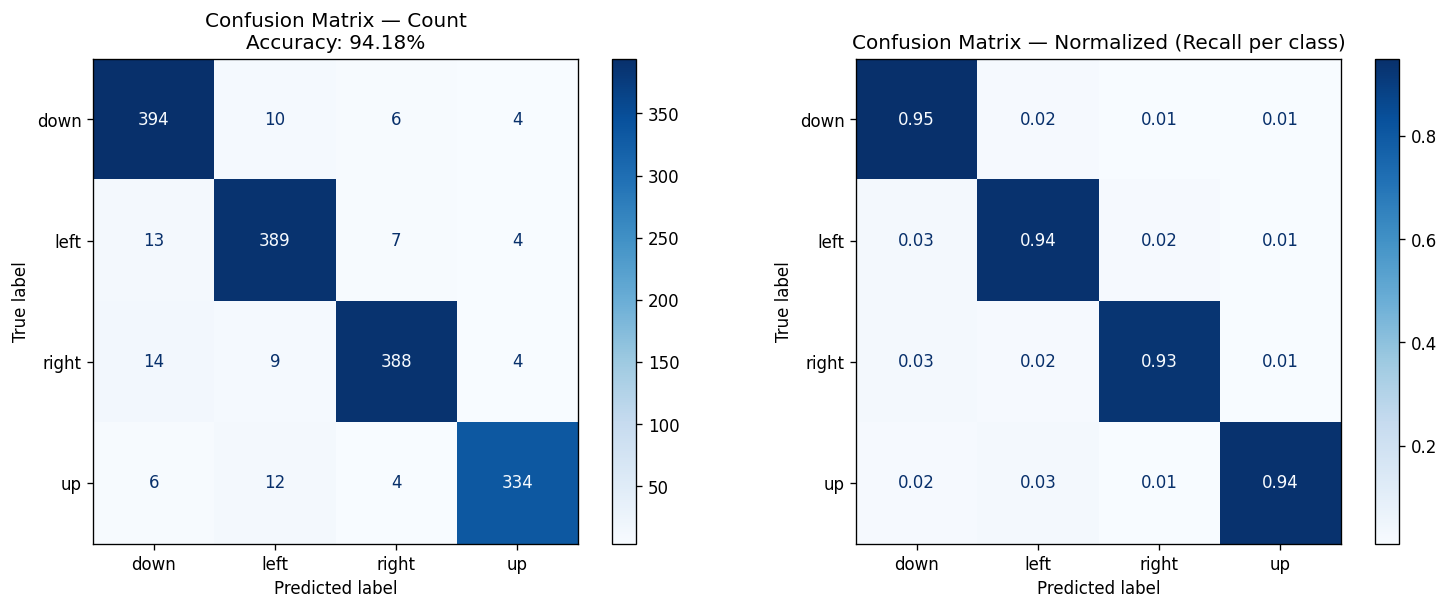

💾 Đã lưu → /content/saved_model/confusion_matrix.png


In [10]:
# ── 7.2 Confusion Matrix (Count + Normalized) ─────────────
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — Count\nAccuracy: {test_acc*100:.2f}%', fontsize=12)

ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(
    ax=axes[1], colorbar=True, cmap='Blues')
axes[1].set_title('Confusion Matrix — Normalized (Recall per class)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print(f'💾 Đã lưu → {SAVE_DIR}/confusion_matrix.png')

⭐ Best: C=10, gamma=0.01, F1=0.9866


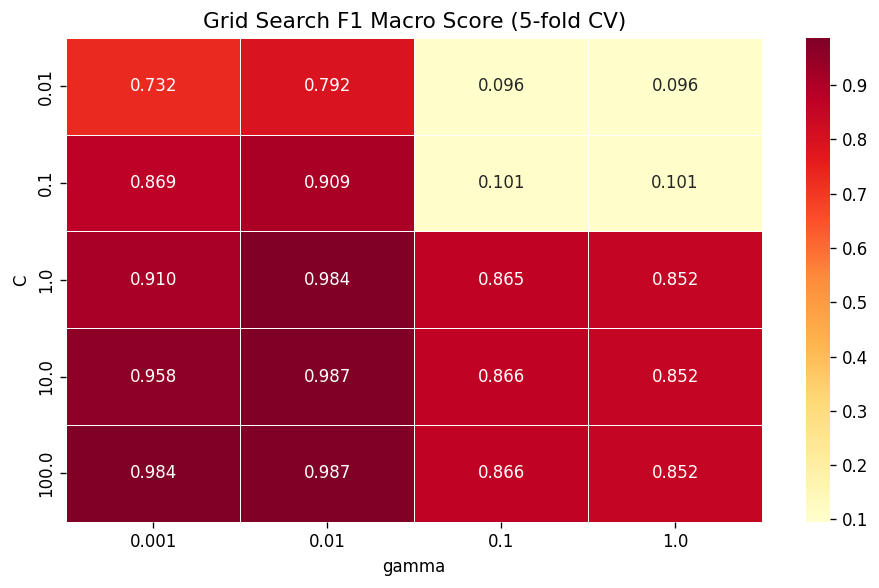

In [11]:
# ── 7.3 Grid Search Heatmap ───────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
pivot   = results.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Grid Search F1 Macro Score (5-fold CV)', fontsize=13)
ax.set_xlabel('gamma')
ax.set_ylabel('C')
print(f'⭐ Best: C={grid_search.best_params_["C"]}, gamma={grid_search.best_params_["gamma"]}, '
      f'F1={grid_search.best_score_:.4f}')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/grid_search_heatmap.png', dpi=150)
plt.show()

📊 AUC scores:
   down  : 0.9958
   left  : 0.9932
   right : 0.9950
   up    : 0.9959
   Macro AUC: 0.9950


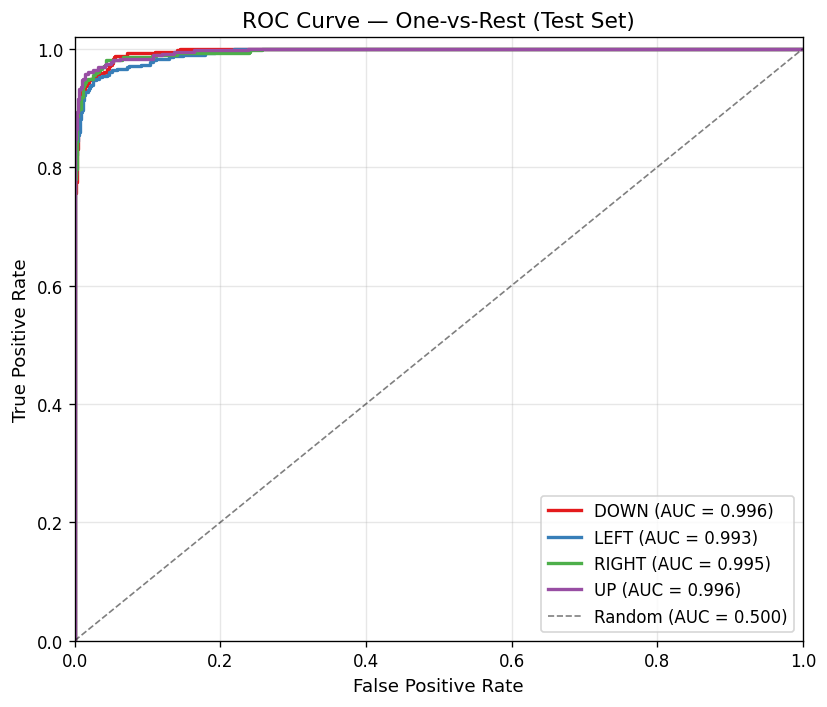

In [12]:
# ── 7.4 ROC Curve (One-vs-Rest) + AUC ────────────────────
y_test_bin = label_binarize(y_test, classes=list(range(len(le.classes_))))

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
auc_scores = {}

for i, (cls_name, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls_name] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name.upper()} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — One-vs-Rest (Test Set)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

macro_auc = np.mean(list(auc_scores.values()))
print(f'📊 AUC scores:')
for cls, a in auc_scores.items():
    print(f'   {cls:6s}: {a:.4f}')
print(f'   Macro AUC: {macro_auc:.4f}')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curve.png', dpi=150)
plt.show()

🔄 Đang tính learning curve ...
📊 Learning curve (full train):
   Train F1 : 1.0000 ± 0.0000
   Val   F1 : 0.9523 ± 0.0043
   Gap      : 0.0477 ✅ (nhẹ, ổn)


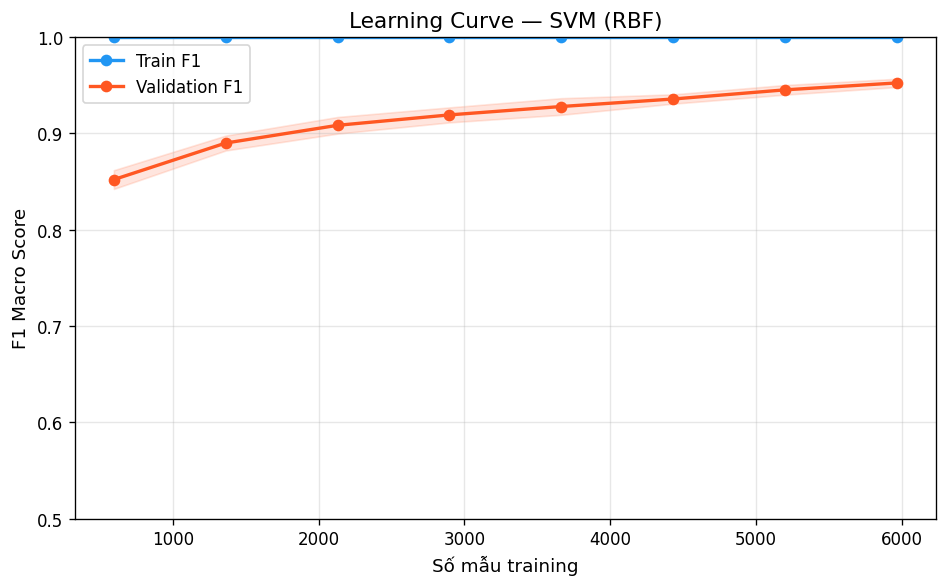

In [13]:
# ── 7.5 Learning Curve ────────────────────────────────────
# Dùng pipeline (scaler + svm) để tránh data leakage khi cross-validate
print('🔄 Đang tính learning curve ...')

# Dùng dữ liệu trước augment (1/2 đầu của X_train sau shuffle)
n_orig = len(X_train) // 2
X_lc, y_lc = X_train[:n_orig], y_train[:n_orig]

pipe_lc = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=best_model.C, gamma=best_model.gamma, kernel='rbf',
        probability=True, class_weight='balanced',
        decision_function_shape='ovr', random_state=RANDOM_STATE
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe_lc, X_lc, y_lc,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)

tr_mean, tr_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
va_mean, va_std = np.mean(val_scores,   axis=1), np.std(val_scores,   axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#2196F3', lw=2, label='Train F1')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, va_mean, 'o-', color='#FF5722', lw=2, label='Validation F1')
ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#FF5722')
ax.set_xlabel('Số mẫu training', fontsize=11)
ax.set_ylabel('F1 Macro Score', fontsize=11)
ax.set_title('Learning Curve — SVM (RBF)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0.5, 1.0])

gap = tr_mean[-1] - va_mean[-1]
print(f'📊 Learning curve (full train):')
print(f'   Train F1 : {tr_mean[-1]:.4f} ± {tr_std[-1]:.4f}')
print(f'   Val   F1 : {va_mean[-1]:.4f} ± {va_std[-1]:.4f}')
print(f'   Gap      : {gap:.4f}', '✅ (nhẹ, ổn)' if gap < 0.05 else '⚠️ (cần thêm data)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/learning_curve.png', dpi=150)
plt.show()

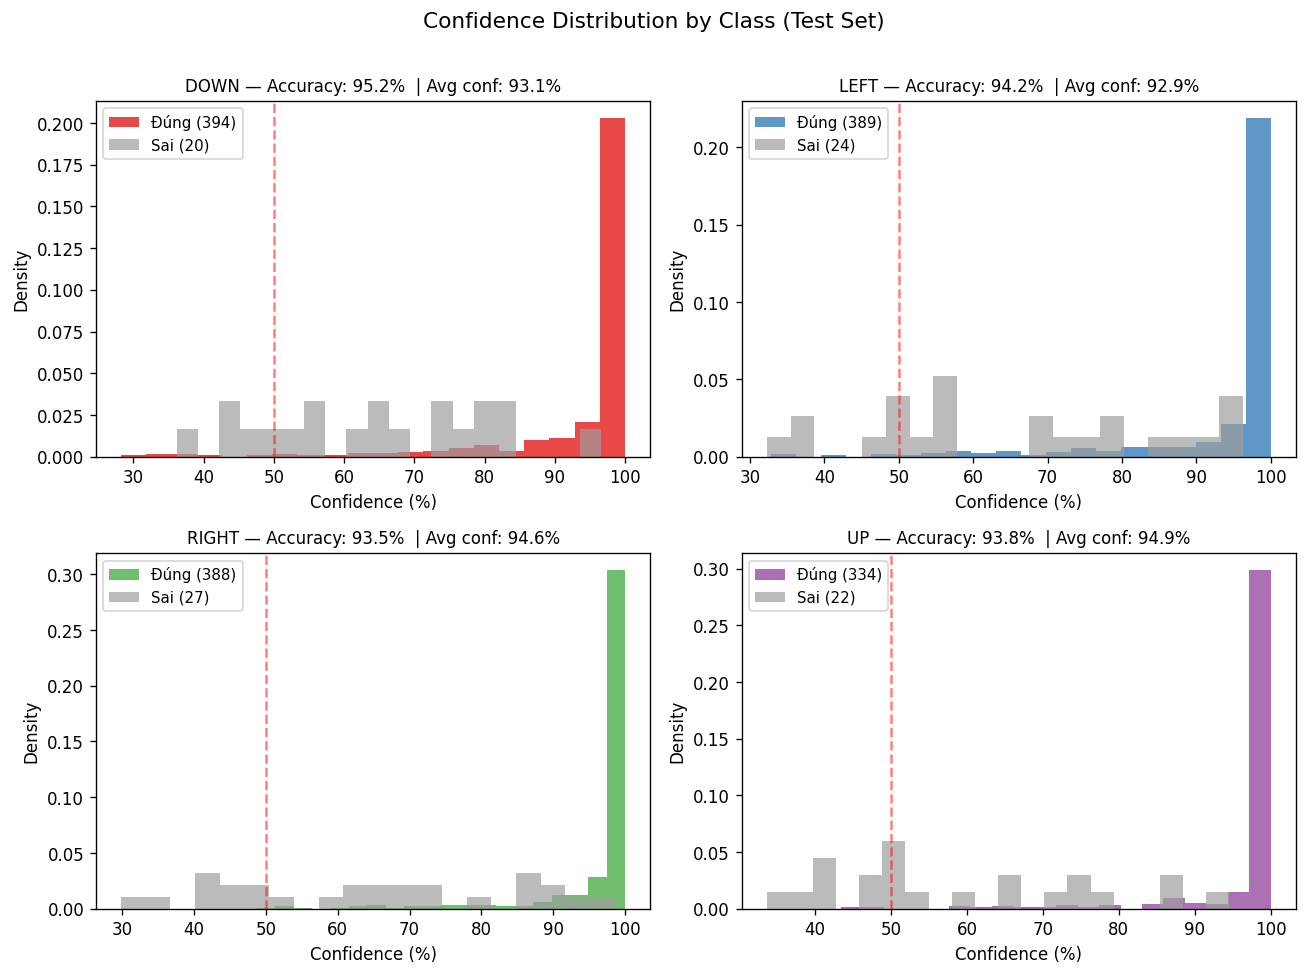


📊 TỔNG KẾT ĐÁNH GIÁ
   Test Accuracy : 94.18%
   Test F1 Macro : 0.9422
   Macro AUC     : 0.9950
   Feature dims  : 168 chiều
   Best SVM      : C=10, gamma=0.01


In [14]:
# ── 7.6 Confidence Histogram theo lớp ─────────────────────
# Phân tích phân phối confidence — nhận biết lớp nào mô hình còn do dự
conf_max = np.max(y_test_proba, axis=1) * 100

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
axes = axes.flatten()
colors_hist = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for i, (cls_name, color) in enumerate(zip(le.classes_, colors_hist)):
    mask_true  = (y_test == i)
    conf_cls   = conf_max[mask_true]
    correct    = (y_test_pred[mask_true] == i)

    axes[i].hist(conf_cls[correct],  bins=20, color=color,
                 alpha=0.8, label=f'Đúng ({correct.sum()})', density=True)
    axes[i].hist(conf_cls[~correct], bins=20, color='#9e9e9e',
                 alpha=0.7, label=f'Sai ({(~correct).sum()})', density=True)
    axes[i].axvline(50, color='red', linestyle='--', alpha=0.5, lw=1.5)
    axes[i].set_title(
        f'{cls_name.upper()} — Accuracy: {correct.mean()*100:.1f}%  '
        f'| Avg conf: {conf_cls.mean():.1f}%', fontsize=10)
    axes[i].set_xlabel('Confidence (%)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

fig.suptitle('Confidence Distribution by Class (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confidence_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tổng kết ──────────────────────────────────────────────
print('\n' + '=' * 58)
print('📊 TỔNG KẾT ĐÁNH GIÁ')
print('=' * 58)
print(f'   Test Accuracy : {test_acc*100:.2f}%')
print(f'   Test F1 Macro : {test_f1:.4f}')
print(f'   Macro AUC     : {macro_auc:.4f}')
print(f'   Feature dims  : {X_test_s.shape[1]} chiều')
print(f'   Best SVM      : C={best_model.C}, gamma={best_model.gamma}')

## 💾 Bước 8: Lưu Model

**4 file cần lưu lại:**
| File | Vai trò |
|---|---|
| `svm_model.pkl` | Model SVM đã train |
| `scaler.pkl` | Chuẩn hóa đặc trưng |
| `label_encoder.pkl` | Mapping số → tên lớp |
| `config.pkl` | Tham số MFCC dùng khi inference |

In [15]:
MODEL_PATH  = f'{SAVE_DIR}/svm_model.pkl'
SCALER_PATH = f'{SAVE_DIR}/scaler.pkl'
LABEL_PATH  = f'{SAVE_DIR}/label_encoder.pkl'
CONFIG_PATH = f'{SAVE_DIR}/config.pkl'

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler,     SCALER_PATH)
joblib.dump(le,         LABEL_PATH)
joblib.dump({
    'sample_rate'  : SAMPLE_RATE,
    'duration'     : DURATION,
    'n_mfcc'       : N_MFCC,
    'n_fft'        : N_FFT,
    'hop_length'   : HOP_LENGTH,
    'win_length'   : WIN_LENGTH,
    'feature_dim'  : X_test_s.shape[1],
    'class_names'  : CLASS_NAMES,
    'test_accuracy': test_acc,
    'test_f1'      : test_f1,
    'macro_auc'    : macro_auc,
    'best_params'  : grid_search.best_params_
}, CONFIG_PATH)

print('💾 Đã lưu model:')
for p in [MODEL_PATH, SCALER_PATH, LABEL_PATH, CONFIG_PATH]:
    size = os.path.getsize(p) / 1024
    print(f'   {Path(p).name:25s} ({size:.1f} KB)')

# ── Tuỳ chọn: lưu thẳng lên Google Drive ────────────────
# import shutil
# DRIVE_SAVE = '/content/drive/MyDrive/speech_model'
# os.makedirs(DRIVE_SAVE, exist_ok=True)
# for f in [MODEL_PATH, SCALER_PATH, LABEL_PATH, CONFIG_PATH]:
#     shutil.copy(f, DRIVE_SAVE)
#     print(f'✅ Đã lưu Drive: {Path(f).name}')

💾 Đã lưu model:
   svm_model.pkl             (8260.5 KB)
   scaler.pkl                (4.5 KB)
   label_encoder.pkl         (0.4 KB)
   config.pkl                (0.4 KB)


## 🎤 Bước 9: Test với file WAV mới

Upload bất kỳ file `.wav` nào để kiểm tra dự đoán.

In [16]:
def predict_audio(file_path, model, scaler, le, verbose=True):
    """Nhận diện 1 file WAV, trả về (nhãn, confidence)."""
    audio     = load_and_preprocess(file_path)
    feature   = extract_features(audio)
    feature_s = scaler.transform([feature])

    pred_idx   = model.predict(feature_s)[0]
    pred_label = le.inverse_transform([pred_idx])[0]
    proba      = model.predict_proba(feature_s)[0]
    confidence = np.max(proba) * 100

    if verbose:
        print(f'\n🎤 File: {Path(file_path).name}')
        print(f'   Dự đoán   : ✅ {pred_label.upper()}')
        print(f'   Confidence: {confidence:.1f}%')
        print(f'   Xác suất từng lớp:')
        for cls, prob in zip(le.classes_, proba):
            bar = '█' * int(prob * 25)
            print(f'      {cls:6s}: {bar:<25s} {prob*100:.1f}%')

    return pred_label, confidence


from google.colab import files
print('🎤 Upload file WAV để test (có thể chọn nhiều file):')
uploaded_test = files.upload()

for fname in uploaded_test.keys():
    predict_audio(f'/content/{fname}', best_model, scaler, le)

🎤 Upload file WAV để test (có thể chọn nhiều file):


Saving down1.wav to down1.wav
Saving left1.wav to left1.wav
Saving right1.wav to right1.wav
Saving up1.wav to up1.wav

🎤 File: down1.wav
   Dự đoán   : ✅ DOWN
   Confidence: 99.2%
   Xác suất từng lớp:
      down  : ████████████████████████  99.2%
      left  :                           0.5%
      right :                           0.3%
      up    :                           0.0%

🎤 File: left1.wav
   Dự đoán   : ✅ LEFT
   Confidence: 98.5%
   Xác suất từng lớp:
      down  :                           0.2%
      left  : ████████████████████████  98.5%
      right :                           1.3%
      up    :                           0.0%

🎤 File: right1.wav
   Dự đoán   : ✅ RIGHT
   Confidence: 99.4%
   Xác suất từng lớp:
      down  :                           0.4%
      left  :                           0.1%
      right : ████████████████████████  99.4%
      up    :                           0.1%

🎤 File: up1.wav
   Dự đoán   : ✅ UP
   Confidence: 100.0%
   Xác suất từng lớp:
    

In [17]:
# ── Test nhanh 10 mẫu ngẫu nhiên từ test set ──────────────
print('🧪 Test nhanh 10 mẫu ngẫu nhiên từ test set:')
print('-' * 50)

np.random.seed(RANDOM_STATE)
indices = np.random.choice(len(X_test), size=10, replace=False)

correct = 0
for i, idx in enumerate(indices):
    pred      = best_model.predict(X_test_s[[idx]])[0]
    true      = y_test[idx]
    pred_name = le.inverse_transform([pred])[0]
    true_name = le.inverse_transform([true])[0]
    match     = '✅' if pred == true else '❌'
    conf      = best_model.predict_proba(X_test_s[[idx]])[0].max() * 100
    print(f'  [{i+1:2d}] True={true_name:6s} Pred={pred_name:6s} {match}  ({conf:.1f}%)')
    if pred == true:
        correct += 1

print(f'\n  Mini accuracy: {correct}/10 = {correct/10*100:.0f}%')

🧪 Test nhanh 10 mẫu ngẫu nhiên từ test set:
--------------------------------------------------
  [ 1] True=down   Pred=down   ✅  (82.3%)
  [ 2] True=right  Pred=right  ✅  (100.0%)
  [ 3] True=up     Pred=up     ✅  (100.0%)
  [ 4] True=down   Pred=down   ✅  (99.7%)
  [ 5] True=right  Pred=right  ✅  (100.0%)
  [ 6] True=right  Pred=right  ✅  (99.4%)
  [ 7] True=up     Pred=up     ✅  (100.0%)
  [ 8] True=right  Pred=right  ✅  (95.7%)
  [ 9] True=down   Pred=down   ✅  (98.3%)
  [10] True=right  Pred=right  ✅  (100.0%)

  Mini accuracy: 10/10 = 100%


---
## 📊 Tóm tắt kết quả

In [18]:
print('=' * 58)
print('📊 TÓM TẮT DỰ ÁN (IMPROVED)')
print('=' * 58)
print(f'  Dataset       : {len(X)} mẫu ({len(CLASS_NAMES)} lớp)')
print(f'  Features      : MFCC+delta+delta²+spectral → {X.shape[1]} chiều')
print(f'  Augmentation  : 2× train set (noise + scale perturbation)')
print(f'  Mô hình       : SVM RBF, class_weight=balanced, OvR')
print(f'  Best params   : {grid_search.best_params_}')
print(f'  Val  Accuracy : {val_acc*100:.2f}%')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test F1 Macro : {test_f1:.4f}')
print(f'  Macro AUC     : {macro_auc:.4f}')
print('=' * 58)

📊 TÓM TẮT DỰ ÁN (IMPROVED)
  Dataset       : 10653 mẫu (4 lớp)
  Features      : MFCC+delta+delta²+spectral → 168 chiều
  Augmentation  : 2× train set (noise + scale perturbation)
  Mô hình       : SVM RBF, class_weight=balanced, OvR
  Best params   : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Val  Accuracy : 92.49%
  Test Accuracy : 94.18%
  Test F1 Macro : 0.9422
  Macro AUC     : 0.9950
